In [1]:
import numpy as np
from qubicpack.qubicfp import qubicfp
import sys,os
import glob

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab

In [2]:
day = '2023-05-27'
data_dir = '/home/qubic/Calib-TD/'+day+'/'
words = ['DomeOpened']
keywords = ['*{}*'.format(word) for word in words]
for keyword in keywords:
    dirs = np.sort(glob.glob(data_dir+keyword))
    print(dirs)

['/home/qubic/Calib-TD/2023-05-27/2023-05-27_04.48.05__SkyDips-2.25V-DomeOpened-Night'
 '/home/qubic/Calib-TD/2023-05-27/2023-05-27_12.40.21__SkyScan-2.25V-DomeOpened-Daytime'
 '/home/qubic/Calib-TD/2023-05-27/2023-05-27_16.28.40__SkyScan-2.5V-DomeOpened-Daytime']


In [ ]:
data_path = "/home/belen/Doctorado/qubic-dev/qubic/qubic/data/Flux_jumps/"
soft_path = "/home/belen/Doctorado/qubic-dev/qubic/qubic/scripts/Calibration/Flux_jumps/"
sys.path.append(os.path.abspath(soft_path))

In [3]:
import jumps_review as jr
import utilities as utils

## 04.48.05 skydip 2.25V

In [4]:
dataset0 = dirs[0]
a = qubicfp()
a.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-05-27 04:48:05.719000
ASIC1 Observation end date: 2023-05-27 06:05:31.791000
ASIC2     Observation date: 2023-05-27 04:48:05.730000
ASIC2 Observation end date: 2023-05-27 06:05:31.791000
No MMR data found in directory: /home/qubic/Calib-TD/2023-05-27/2023-05-27_04.48.05__SkyDips-2.25V-DomeOpened-Night/Hks
No MGC data found in directory: /home/qubic/Calib-TD/2023-05-27/2023-05-27_04.48.05__SkyDips-2.25V-DomeOpened-Night/Hks
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
WARNING! The bias phase is different between the ASICs.  To see where, please set verbosity>2 and rerun bias_phase()
No previously saved filter information: QUBIC_TES_ASIC1_20230527T044805UTC.filter.pickle
No previously saved filter information: QUBIC_TES_ASIC2_20230527T044805UTC.filter.pickle
Not a valid housekeeping ID: MMR_HK
Not a valid housekeeping ID: MGC_HK
Not a valid housekeeping ID: TES STAGE
Please give an asic number
Plea

True

In [6]:
tod = a.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:])) 

suggest nsamples=729088 which is  2^13*89
number of timesamples along every TES in this dataset: (729088,)


In [7]:
tt[-1]/60

77.43463666439057

In [8]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data: idx and TES corrected
# offset: amplitudes of jumps

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data': {},
    'offset': {}
    }

In [9]:
sat = jr.saturation(sat_value=4.19e6, TES_number=256) 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=soft_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  2   3   4   5   7   8  10  14  15  18  22  24  25  26  27  28  30  31
  32  33  35  36  37  38  39  40  41  43  45  50  60  61  62  63  65  66
  67  68  69  70  71  72  75  77  79  82  83  85  86  87  90  91  92  93
  94  95  97 100 102 103 111 114 128 129 130 131 132 133 134 135 136 137
 138 144 145 146 147 148 149 151 152 155 157 158 160 161 162 163 166 167
 168 169 170 171 172 173 174 175 179 180 181 182 183 184 185 186 187 188
 192 193 194 195 196 197 198 199 200 201 202 204 205 206 207 208 209 211
 212 213 214 216 217 219 220 222 223 231 235 239 241 243 244 247 254 255]


In [10]:
thr = [2e5]#, 3e5, 5e5]  # Multiple thresholds for better detection
window_size = 300  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [11]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf, thr_used = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf, 'thr_used': thr_used}


In [12]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [13]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

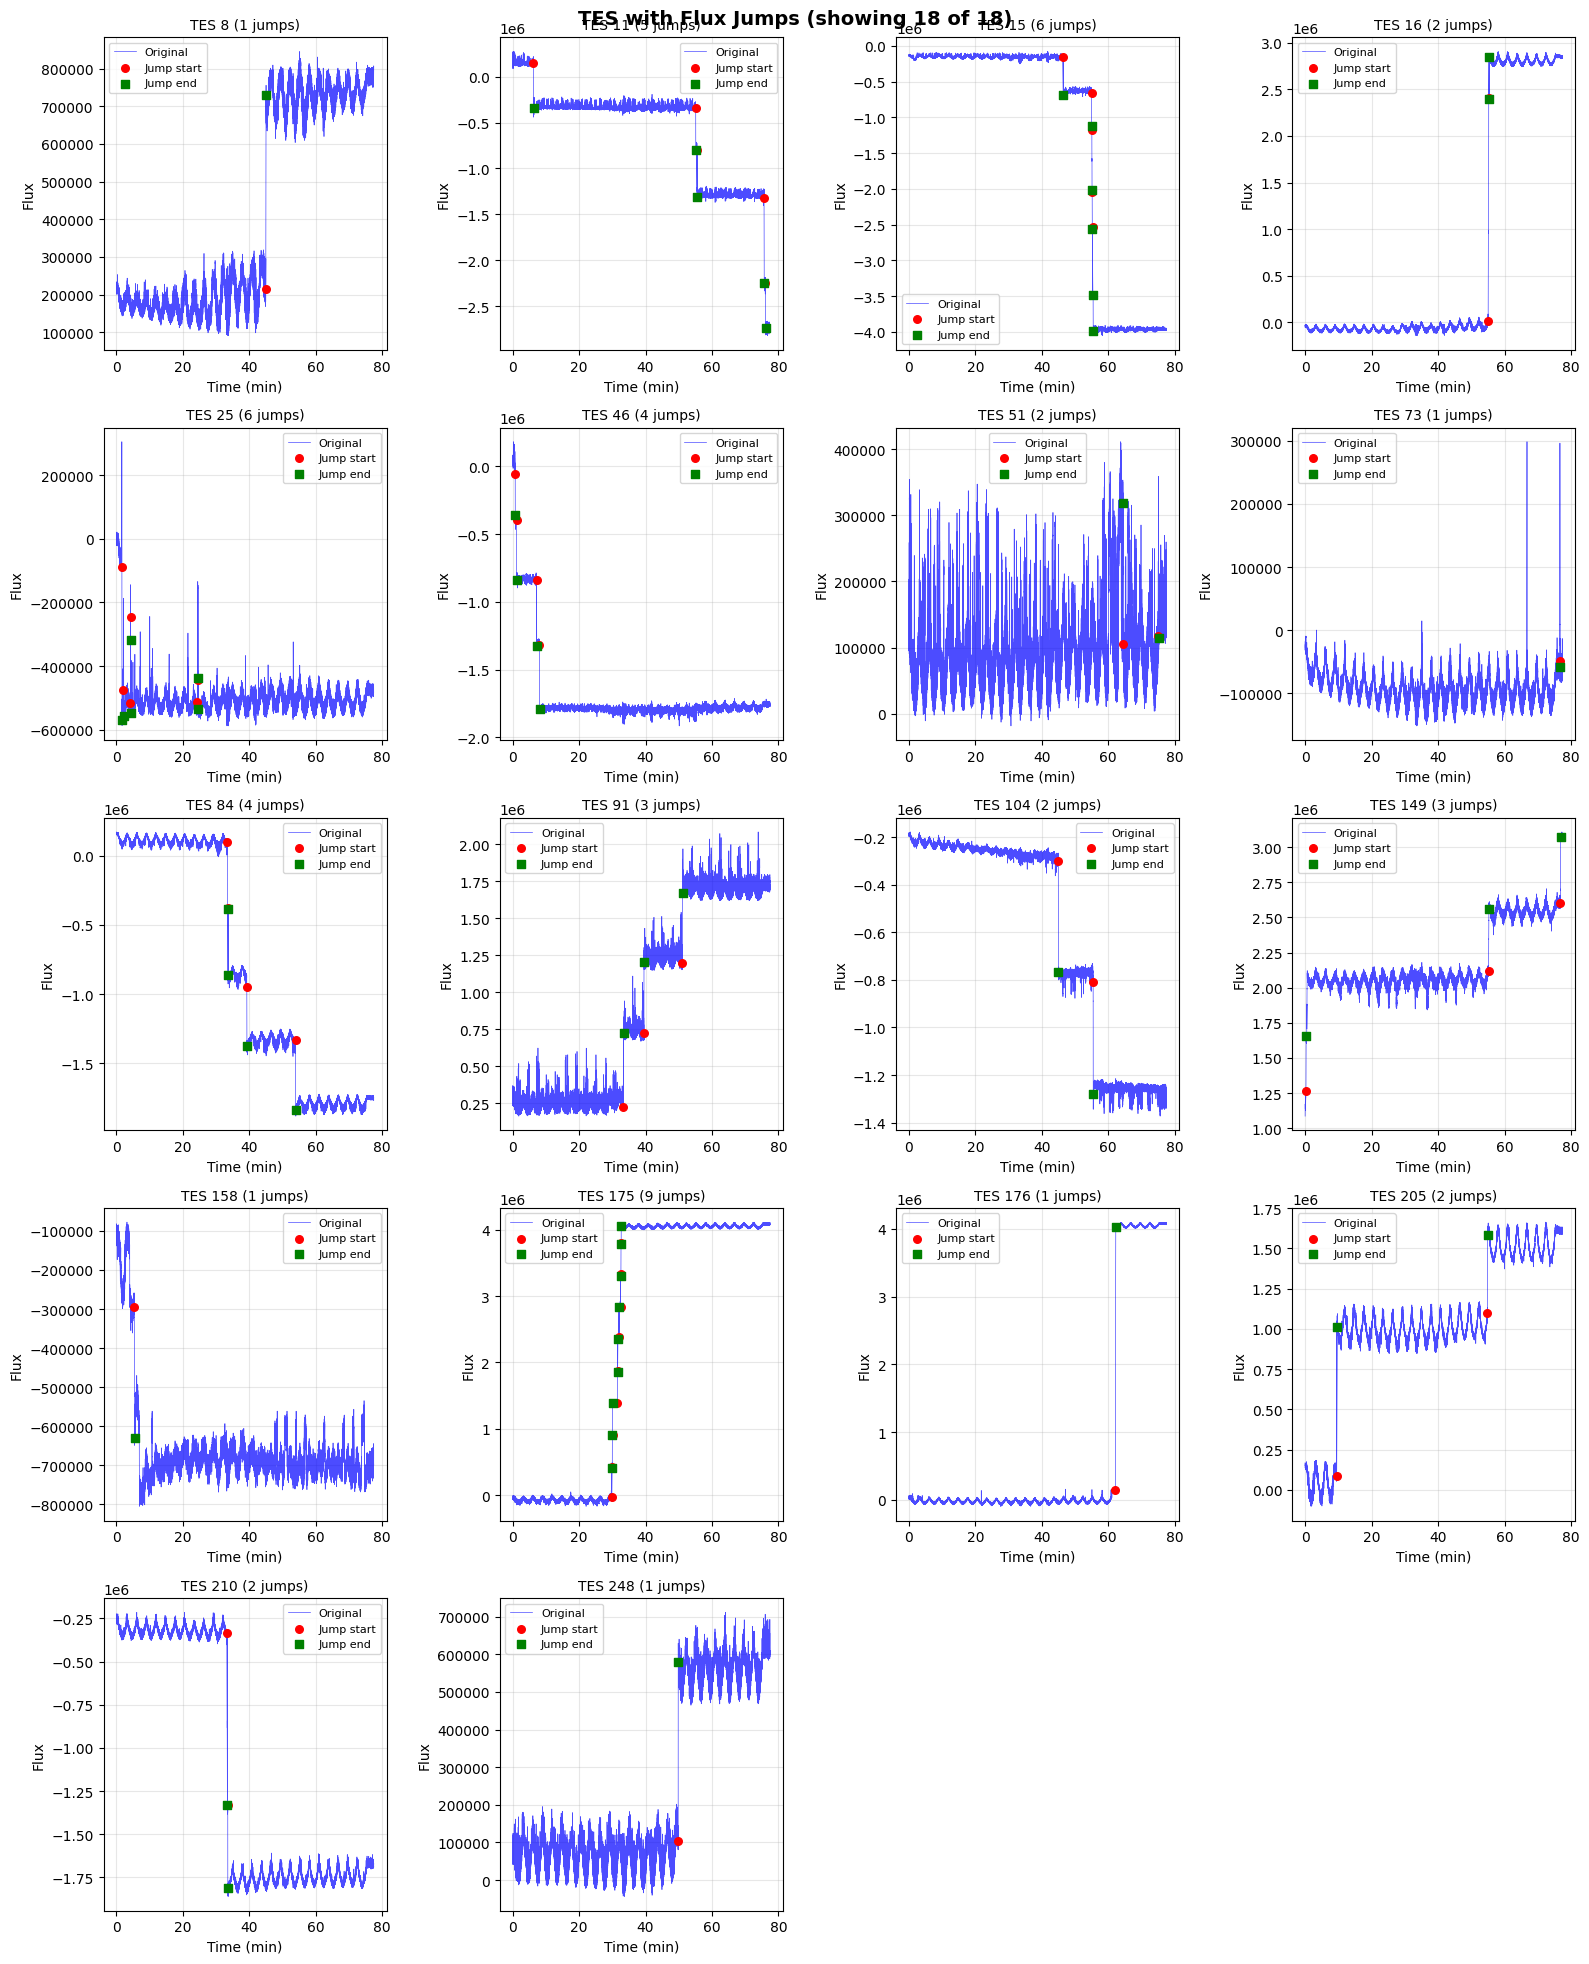

0

In [14]:
utils.plot_jump_detections(tt, todarray, results, DT=False)

In [15]:
# Step 2: Decision Tree Refinement
dt = jr.DT(thr_count=1000, thr_amp=2e5, tol=1e2, depth=True)
dt_jump_data = {}
TES_with_dt_jumps = []
for idx in TES_yes:
    nc = jump_data[idx]['nc']
    xcdt, xcfdt = dt.calculate_levels(tt, todarray[idx], nc, consec=True)
    dt_jump_data[idx] = {'xcdt': xcdt, 'xcfdt': xcfdt, 'ncdt': len(xcdt)}
    if len(xcdt) > 0:
        TES_with_dt_jumps.append(idx)

In [16]:
results['dt_jump_data'] = dt_jump_data
results['TES_yes_dt'] = TES_with_dt_jumps

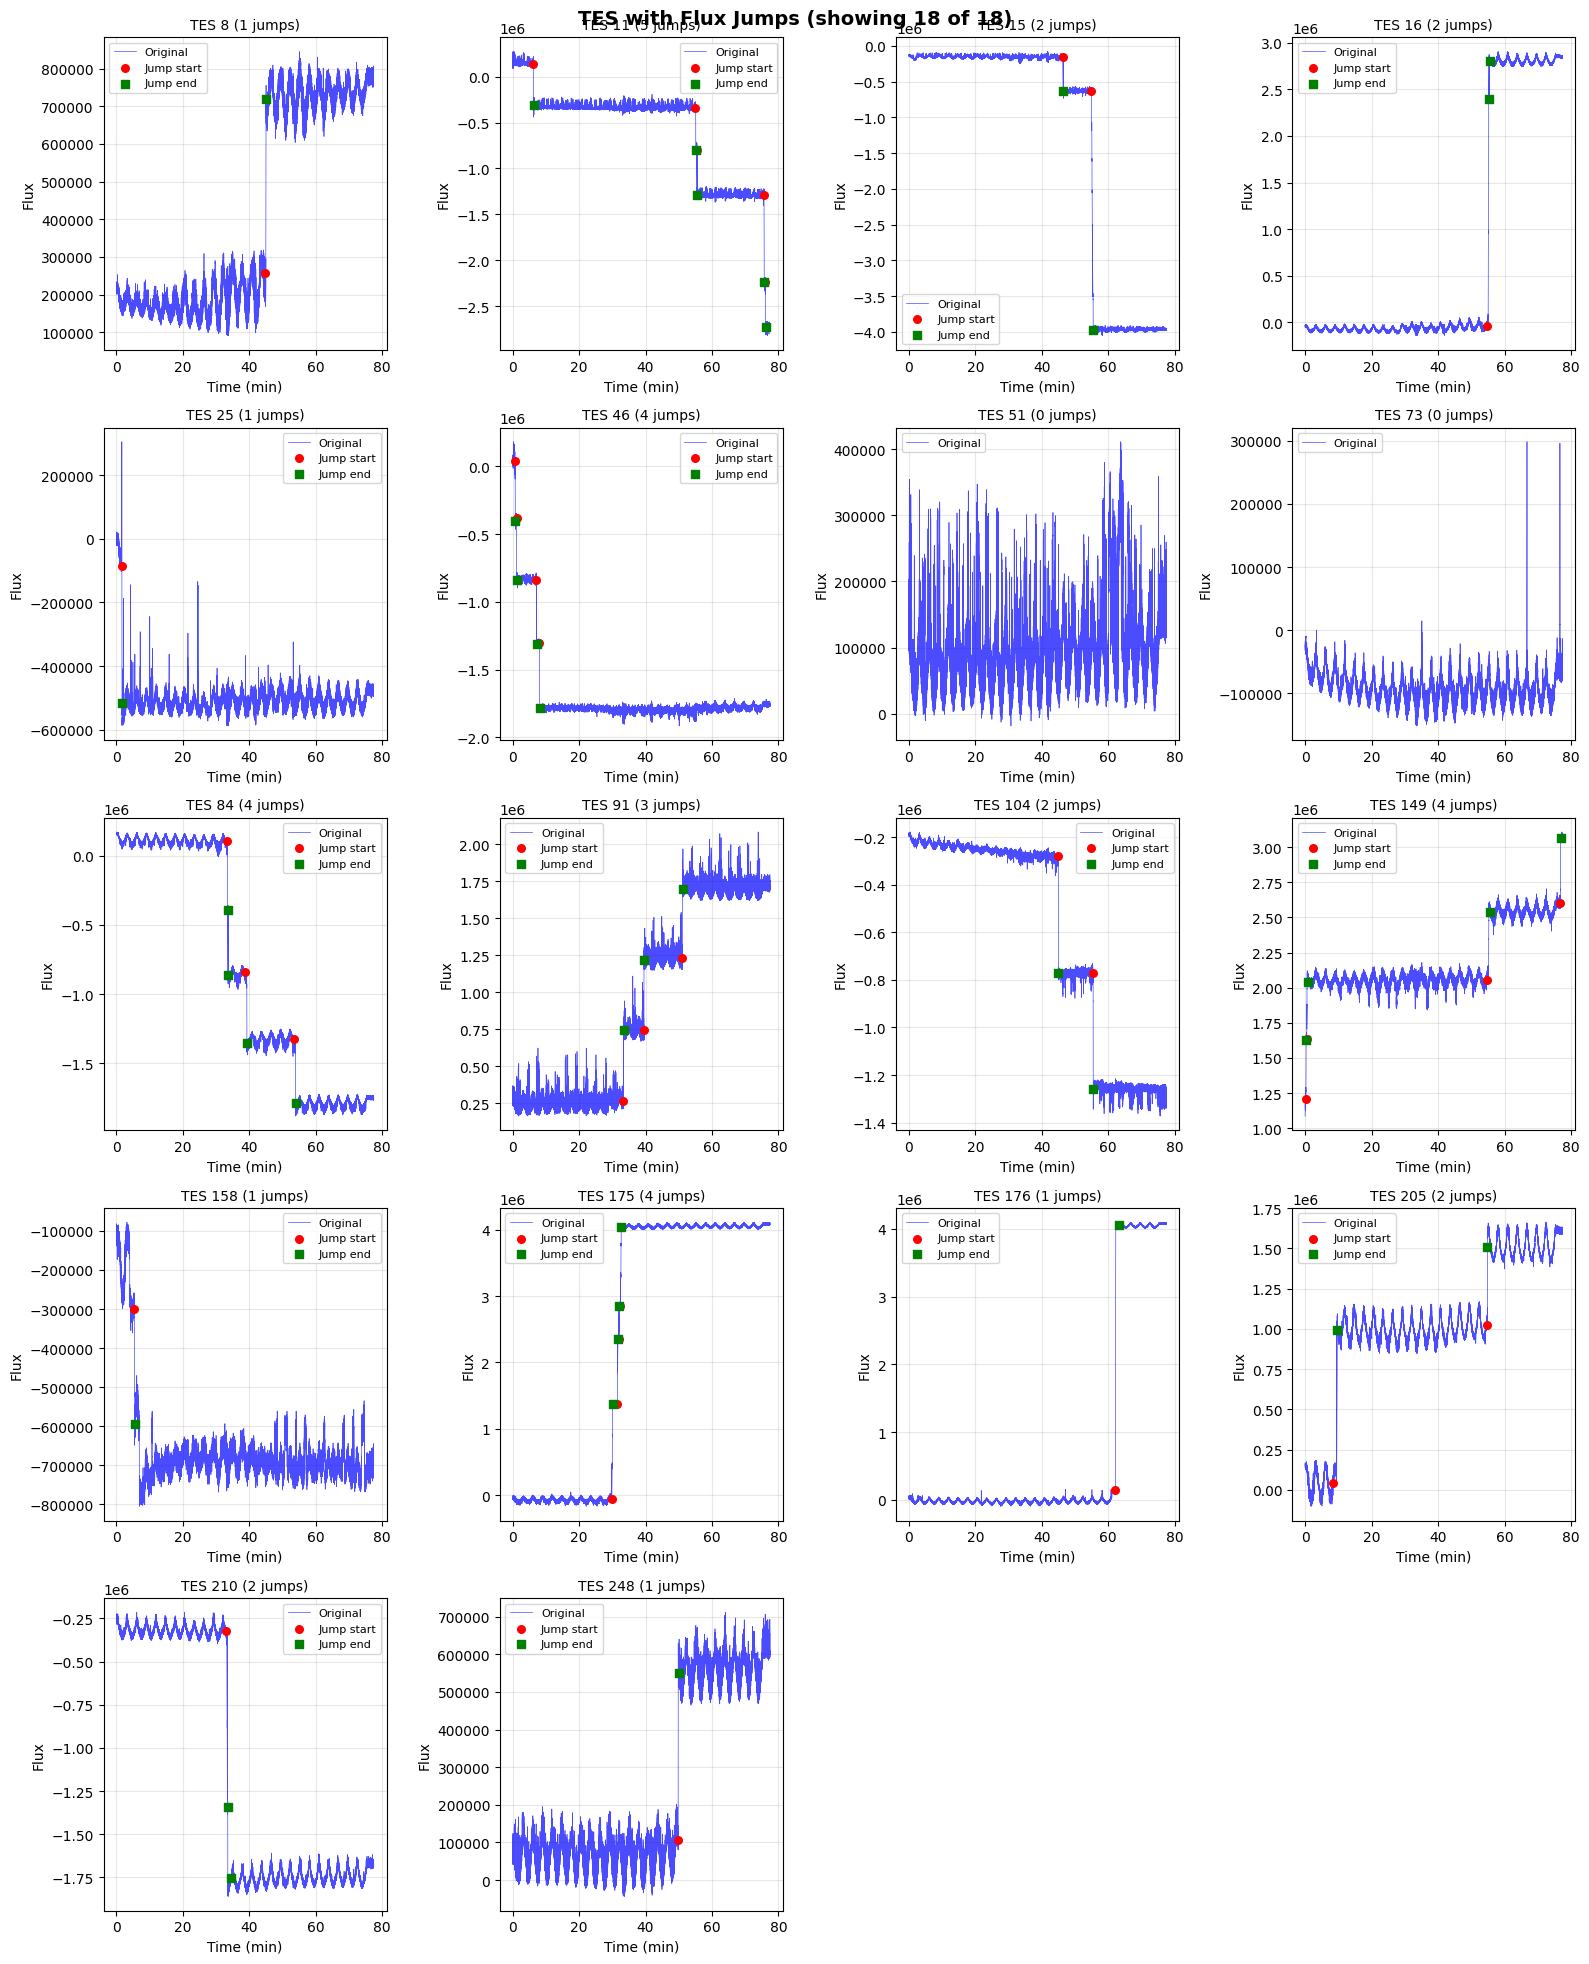

0

In [18]:
utils.plot_jump_detections(tt, todarray, results, DT=True)

In [22]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in dt_jump_data:
        xcdt = dt_jump_data[idx]['xcdt']
        xcfdt = dt_jump_data[idx]['xcfdt']
        nc_dt = dt_jump_data[idx]['ncdt']
        if nc_dt > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xcdt, xcfdt, nc_dt)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xcdt, xcfdt, nc_dt)

In [23]:
results['corrected_data'] = corrected_tod
results['offset'] = offset

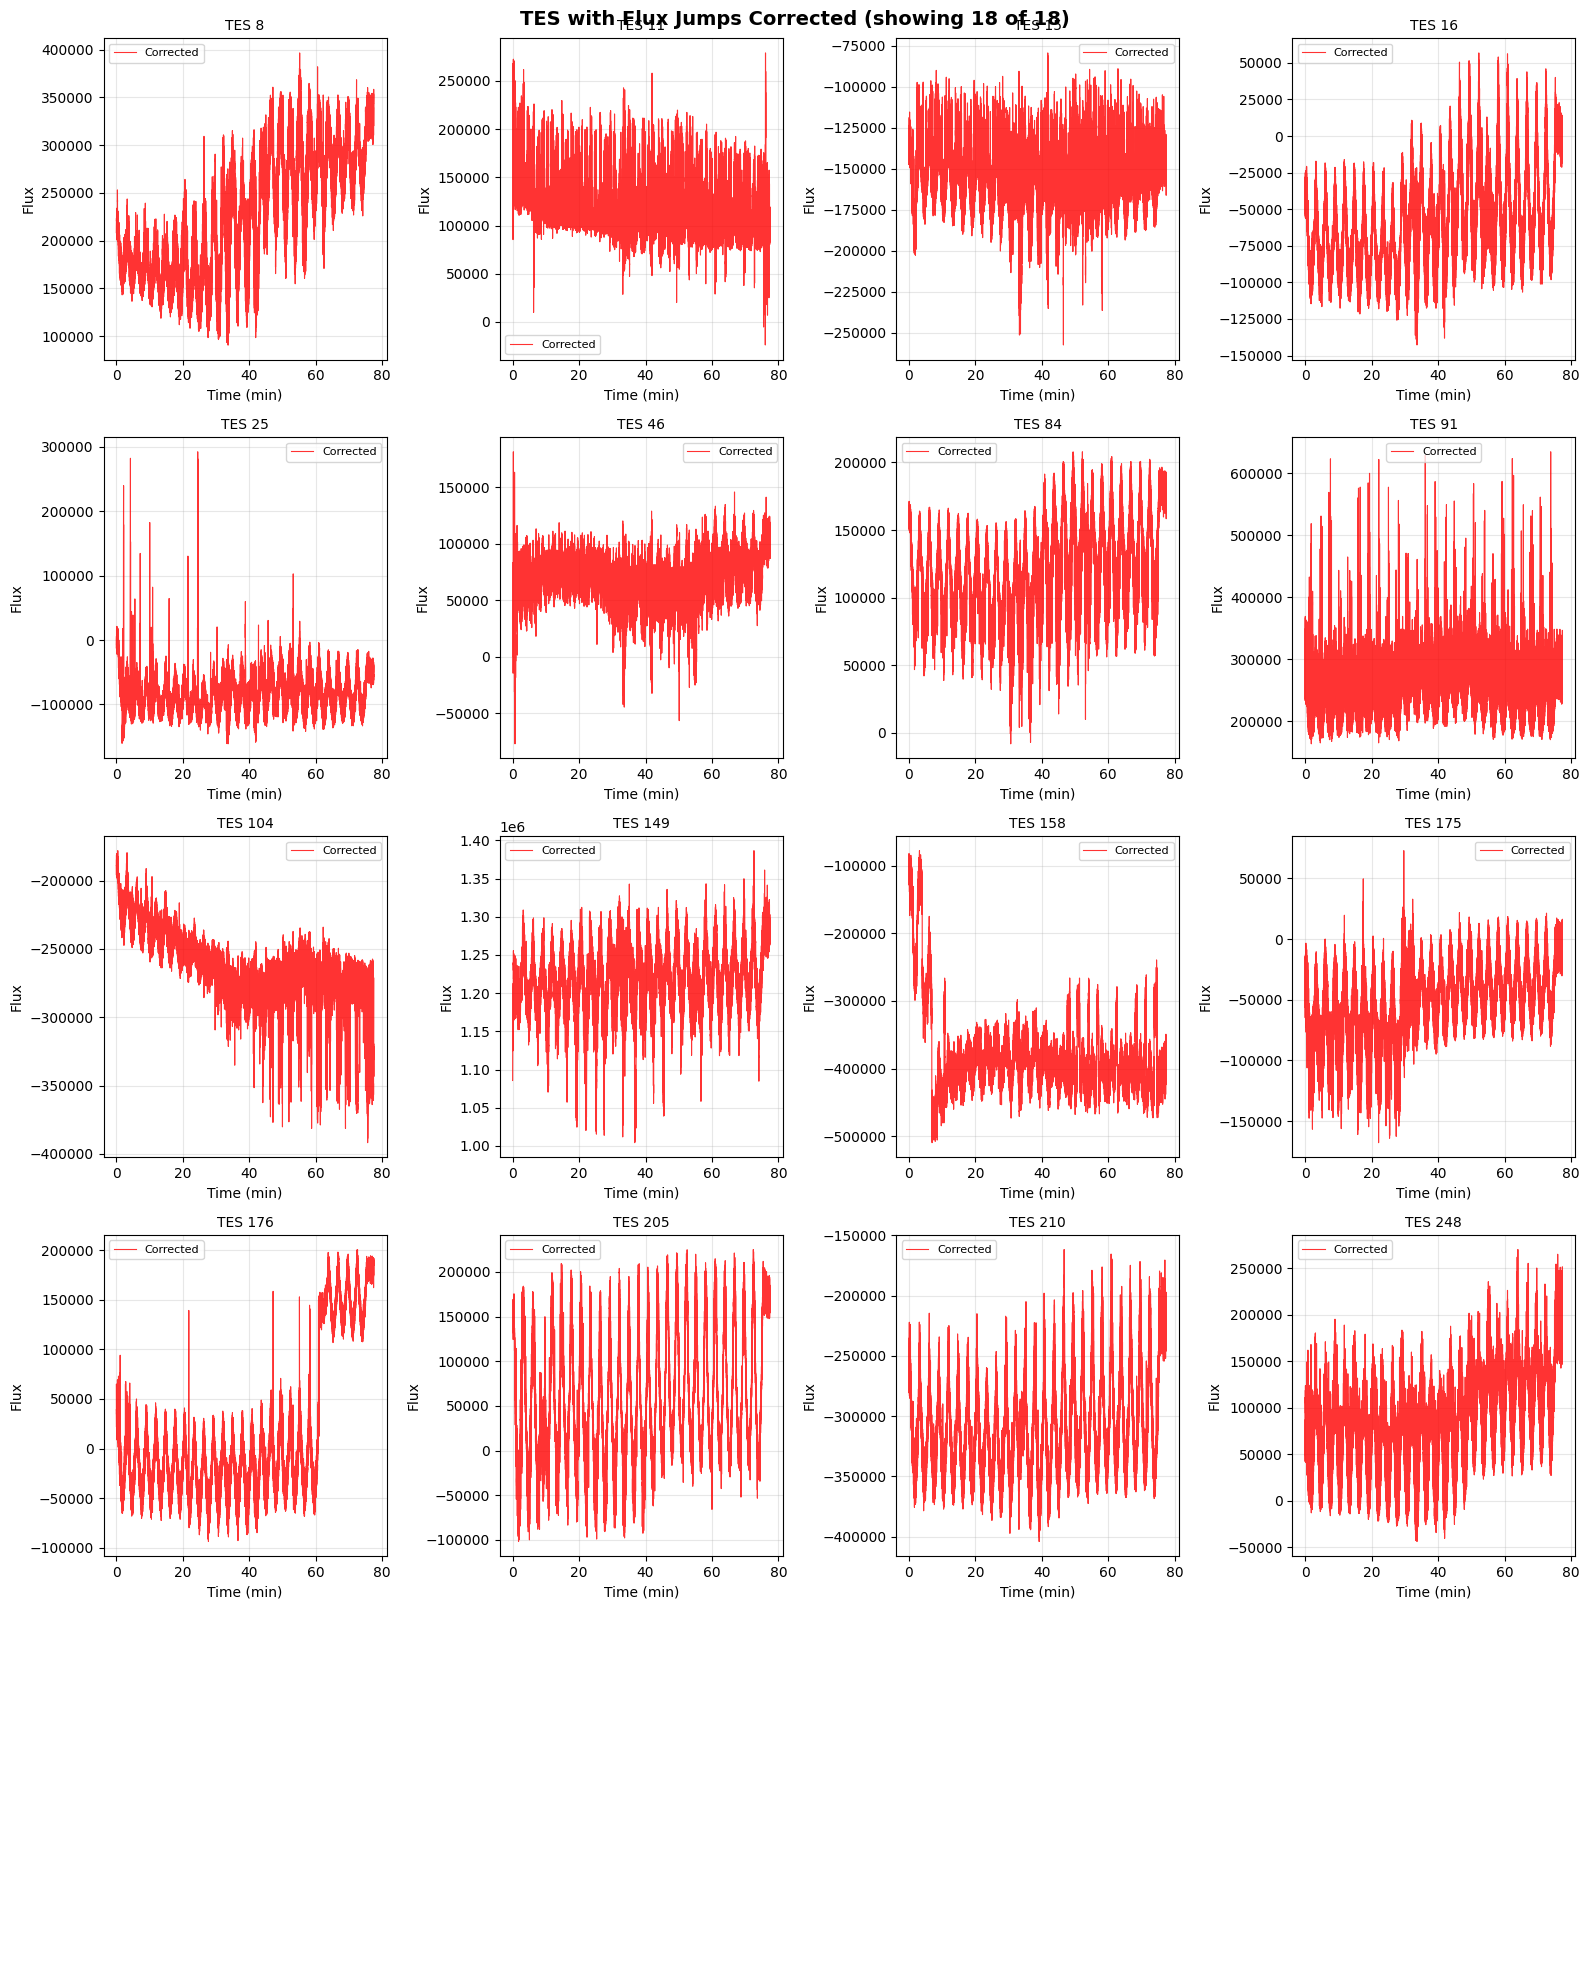

0

In [24]:
utils.plot_corrections(tt, todarray, results)

In [25]:
utils.save_results(results, output_dir=data_path + "year_23_day_2705_04.48.05", dataset_name="23_2705_04.48.05")

Saved pickle file to: ./day_2705_04.48.05/23_2705_04.48.05_results.pkl

All results saved to: ./day_2705_04.48.05
Total files saved: 1



['./day_2705_04.48.05/23_2705_04.48.05_results.pkl']

In [7]:
dirs[1]

'/home/qubic/Calib-TD/2023-05-27/2023-05-27_12.40.21__SkyScan-2.25V-DomeOpened-Daytime'

## skyscan 12.40.21 2.25V

In [8]:
dataset0 = dirs[1]
a1 = qubicfp()
a1.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-05-27 12:40:21.177000
ASIC1 Observation end date: 2023-05-27 16:14:48.742000
ASIC1     Observation date: 2023-05-27 12:40:21.177000
ASIC1 Observation end date: 2023-05-27 16:24:51.338000
ASIC2     Observation date: 2023-05-27 12:40:21.177000
ASIC2 Observation end date: 2023-05-27 16:14:48.741000
ASIC2     Observation date: 2023-05-27 12:40:21.177000
ASIC2 Observation end date: 2023-05-27 16:24:51.338000
No MMR data found in directory: /home/qubic/Calib-TD/2023-05-27/2023-05-27_12.40.21__SkyScan-2.25V-DomeOpened-Daytime/Hks
No MGC data found in directory: /home/qubic/Calib-TD/2023-05-27/2023-05-27_12.40.21__SkyScan-2.25V-DomeOpened-Daytime/Hks
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
WARNING! The bias phase is different between the ASICs.  To see where, please set verbosity>2 and rerun bias_phase()
No previously saved filter information: QUBIC_TES_ASIC1_20230527T124021UTC.filter.pickle
No prev

True

In [9]:
tod = a1.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:])) 

suggest nsamples=2113536 which is  2^14*3*43
number of timesamples along every TES in this dataset: (2113536,)


In [13]:
tt[-1]/60/60

3.741720888879564

In [10]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data: idx and TES corrected
# offset: amplitudes of jumps

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data': {},
    'offset': {}
    }

In [11]:
sat = jr.saturation() 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=soft_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  2   3   4   5   7  13  18  21  22  24  25  26  27  28  30  31  32  33
  35  36  37  38  39  40  41  43  45  50  53  57  58  59  60  61  62  63
  65  66  67  68  69  70  71  72  75  77  79  80  82  83  84  85  86  87
  89  90  91  92  93  94  95  97  98 100 102 103 104 105 108 109 110 111
 114 121 123 128 129 130 131 132 133 134 135 136 137 140 141 142 144 145
 149 152 155 157 160 161 162 163 166 167 169 170 171 173 175 177 178 179
 180 181 182 184 185 186 187 188 192 193 194 195 196 197 198 199 200 201
 202 204 205 207 208 209 211 212 213 214 216 217 219 220 222 223 224 231
 233 235 236 239 241 244 245 248 251 254 255]


In [14]:
iv_idx = np.where(iv_mask == False)[0]
iv_tod = todarray[iv_idx, :]
iv_idx

array([ 16,  17,  23,  42,  44,  46,  47,  64,  73,  78,  96,  99, 101,
       113, 117, 118, 119, 122, 124, 125, 126, 127, 143, 153, 154, 156,
       165, 176, 189, 190, 191, 218, 221, 225, 226, 227, 228, 229, 230,
       249, 250, 252, 253])

In [21]:
thr = [2e5]#, 3e5, 5e5]  # Multiple thresholds for better detection
window_size = 500  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [22]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf, thr_used = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf, 'thr_used': thr_used}


In [23]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [24]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

In [25]:
len(TES_yes)

9

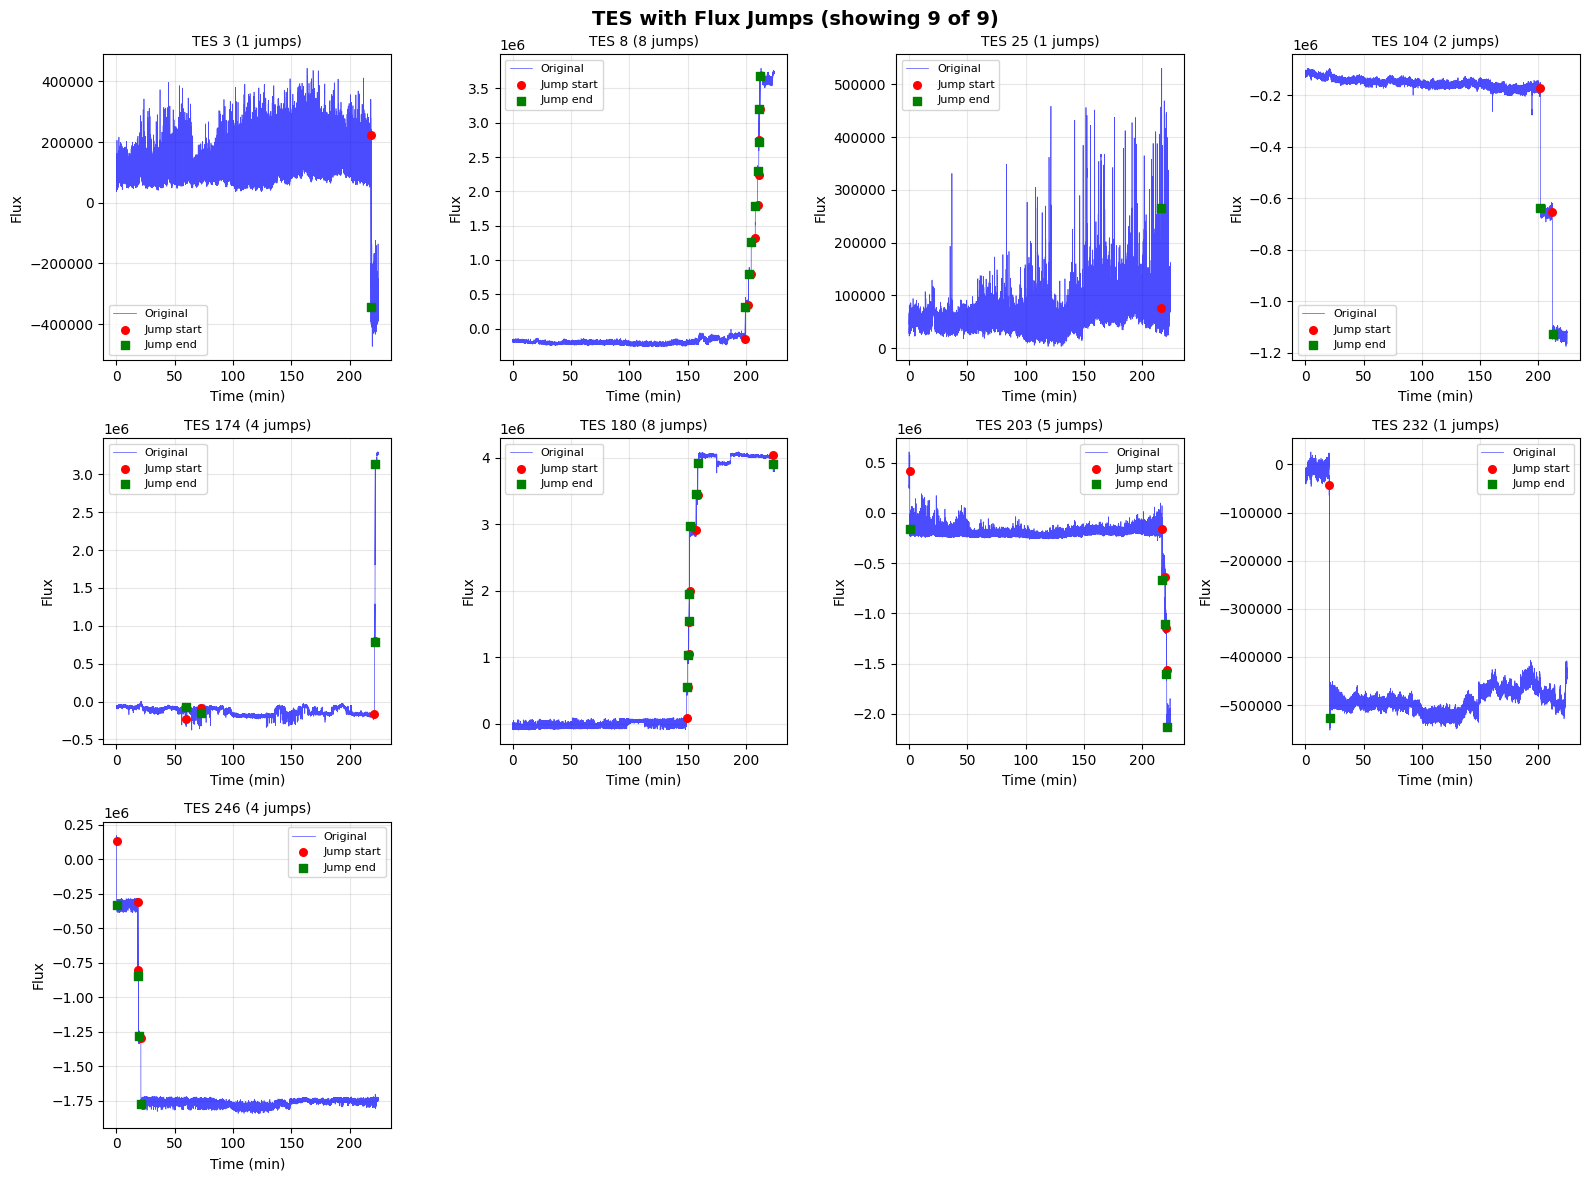

0

In [26]:
utils.plot_jump_detections(tt, todarray, results, DT=False)

In [27]:
# Step 2: Decision Tree Refinement
dt = jr.DT(thr_count=1000, thr_amp=2e5, tol=1e2, depth=True)
dt_jump_data = {}
TES_with_dt_jumps = []
for idx in TES_yes:
    nc = jump_data[idx]['nc']
    xcdt, xcfdt = dt.calculate_levels(tt, todarray[idx], nc, consec=True)
    dt_jump_data[idx] = {'xcdt': xcdt, 'xcfdt': xcfdt, 'ncdt': len(xcdt)}
    if len(xcdt) > 0:
        TES_with_dt_jumps.append(idx)

In [28]:
results['dt_jump_data'] = dt_jump_data
results['TES_yes_dt'] = TES_with_dt_jumps

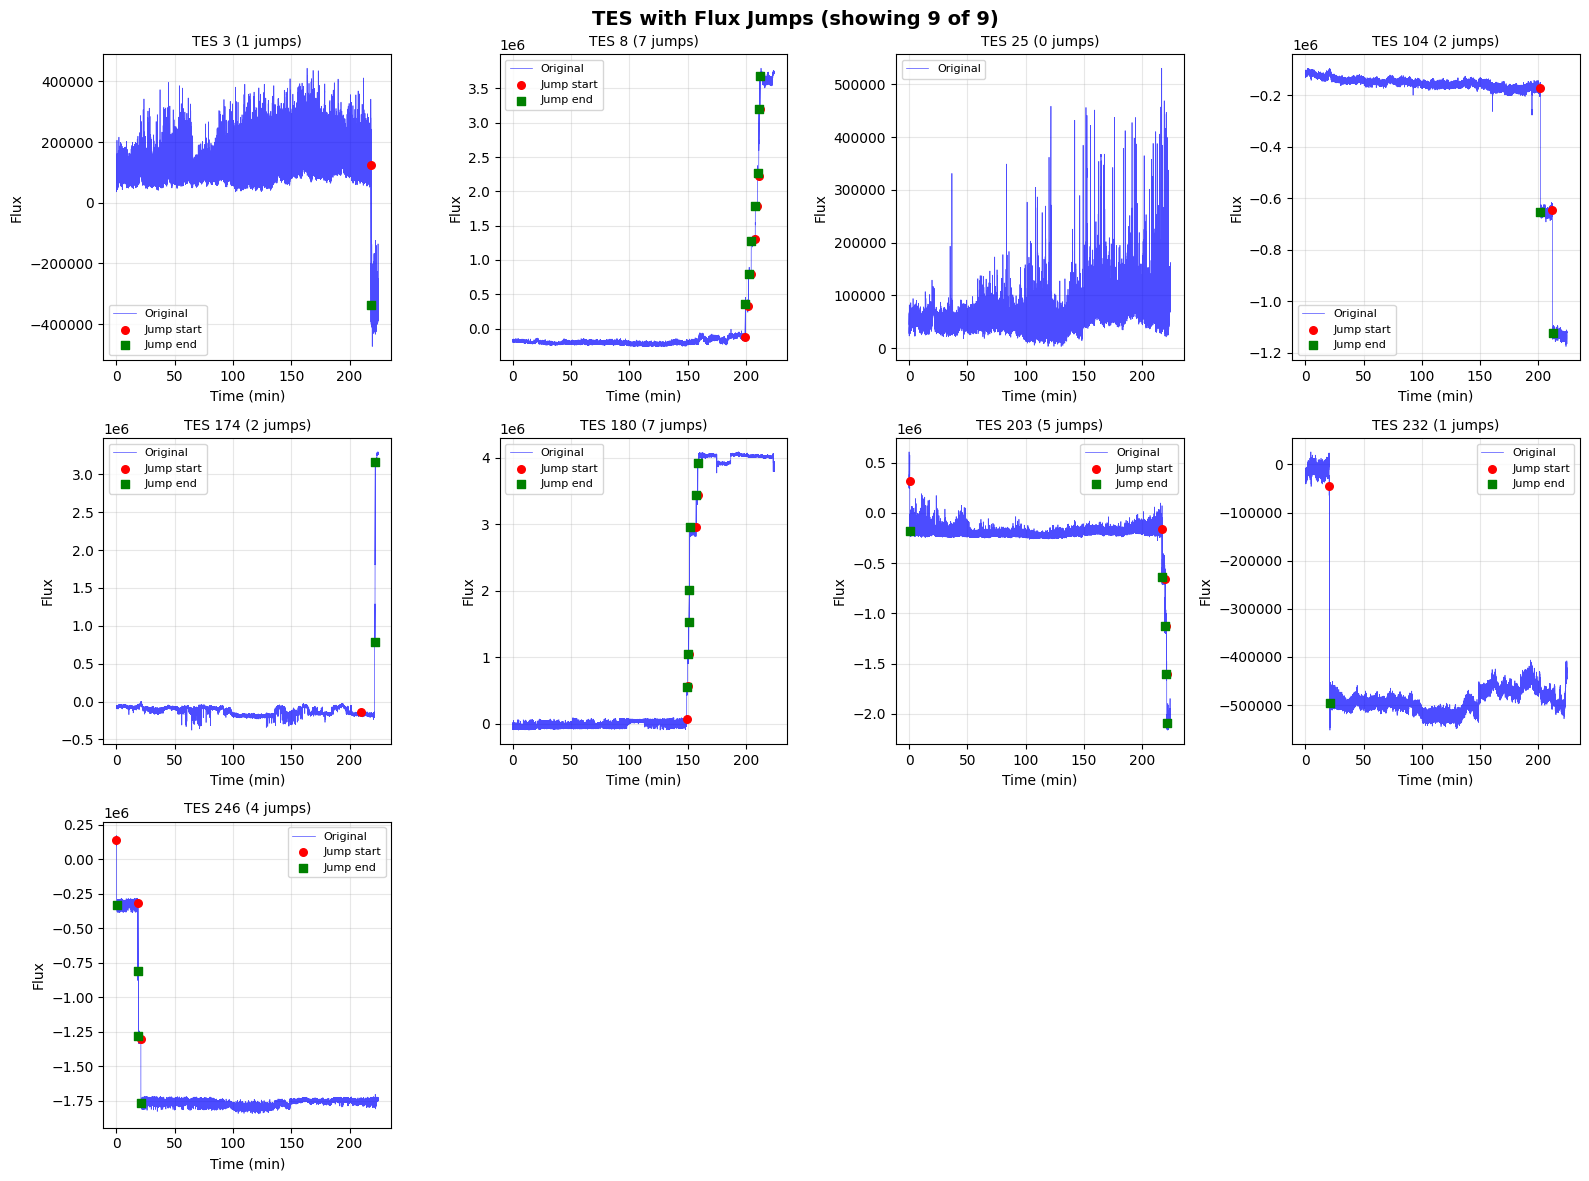

0

In [29]:
utils.plot_jump_detections(tt, todarray, results, DT=True)

In [30]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in dt_jump_data:
        xcdt = dt_jump_data[idx]['xcdt']
        xcfdt = dt_jump_data[idx]['xcfdt']
        nc_dt = dt_jump_data[idx]['ncdt']
        if nc_dt > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xcdt, xcfdt, nc_dt)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xcdt, xcfdt, nc_dt)

In [31]:
results['corrected_data'] = corrected_tod
results['offset'] = offset

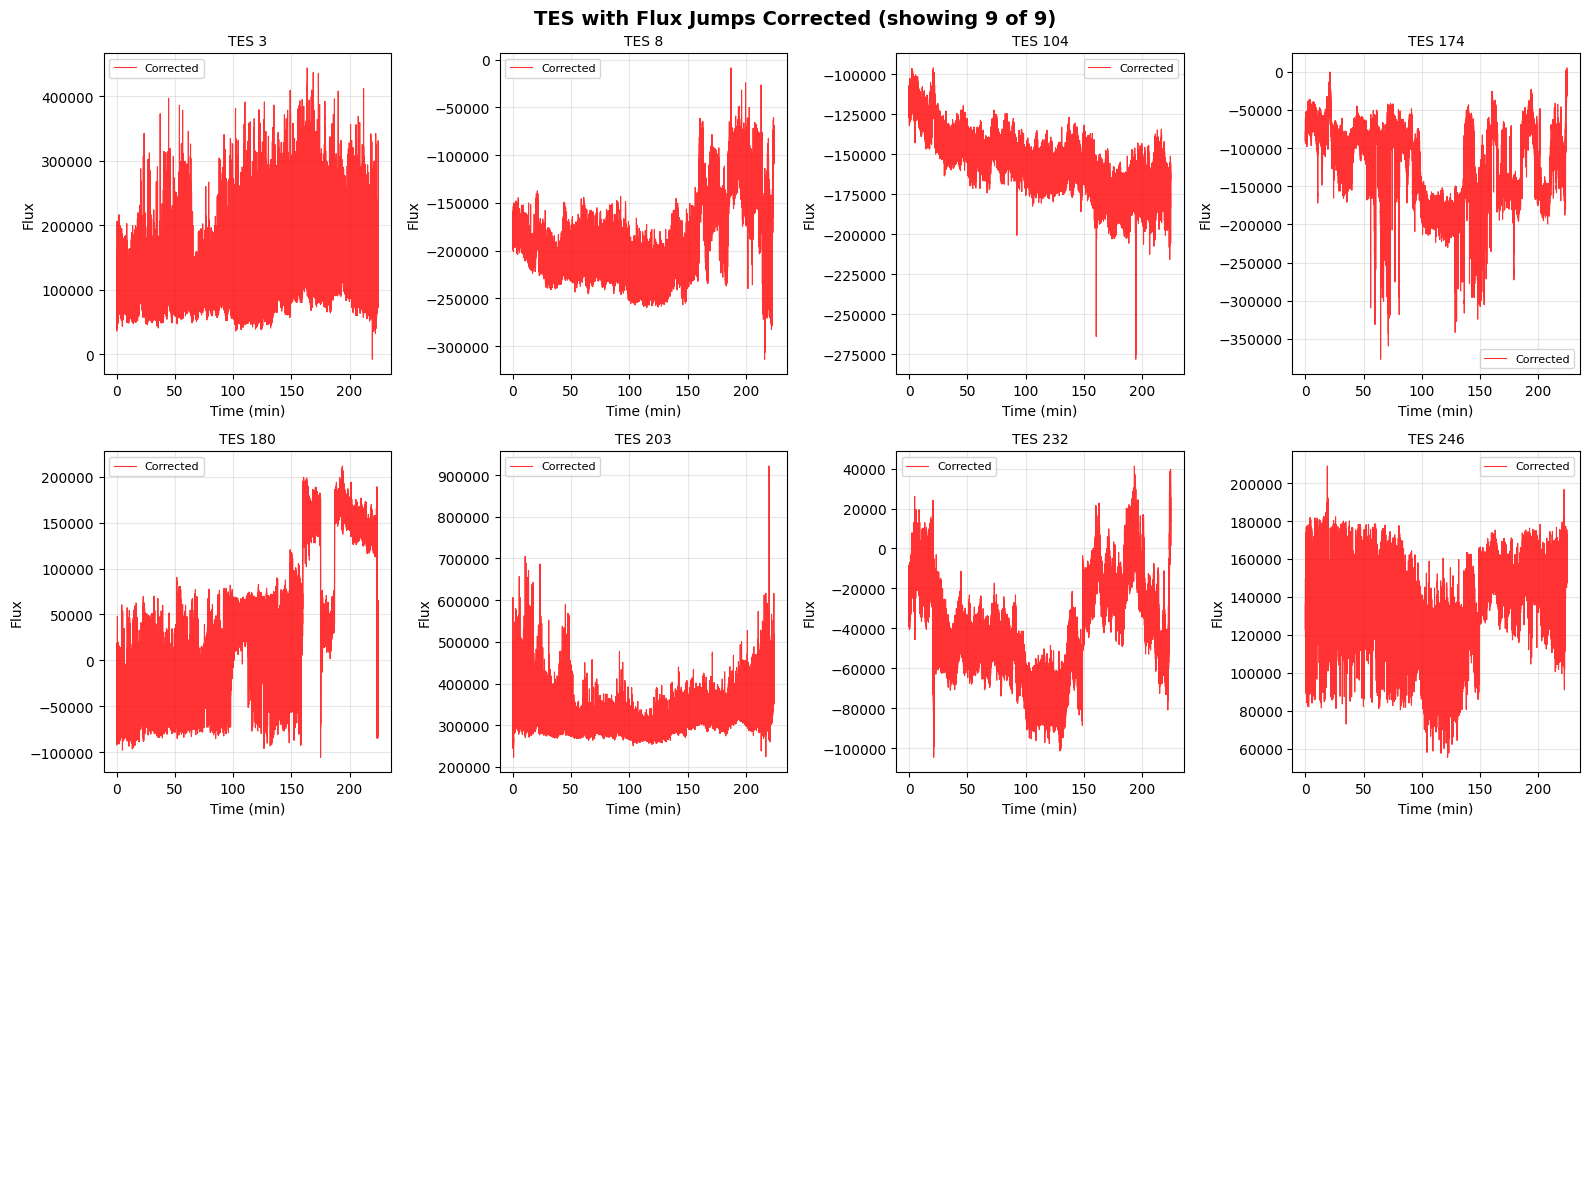

0

In [32]:
utils.plot_corrections(tt, todarray, results)

In [33]:
utils.save_results(results, output_dir=data_path + "year_23_day_2705_12.40.21", dataset_name="23_2705_12.40.21")

Saved pickle file to: ./day_2705_12.40.21/23_2705_12.40.21_results.pkl

All results saved to: ./day_2705_12.40.21
Total files saved: 1



['./day_2705_12.40.21/23_2705_12.40.21_results.pkl']

In [5]:
dirs[2]

'/home/qubic/Calib-TD/2023-05-27/2023-05-27_16.28.40__SkyScan-2.5V-DomeOpened-Daytime'

## 16.28.40 skyscan 2.5V

In [4]:
dataset0 = dirs[2]
a2 = qubicfp()
a2.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-05-27 16:28:40.316000
ASIC1 Observation end date: 2023-05-27 20:03:07.899000
ASIC1     Observation date: 2023-05-27 16:28:40.316000
ASIC1 Observation end date: 2023-05-27 20:12:32.293000
ASIC2     Observation date: 2023-05-27 16:28:40.334000
ASIC2 Observation end date: 2023-05-27 20:03:11.232000
ASIC2     Observation date: 2023-05-27 16:28:40.334000
ASIC2 Observation end date: 2023-05-27 20:12:32.293000
No MMR data found in directory: /home/qubic/Calib-TD/2023-05-27/2023-05-27_16.28.40__SkyScan-2.5V-DomeOpened-Daytime/Hks
No MGC data found in directory: /home/qubic/Calib-TD/2023-05-27/2023-05-27_16.28.40__SkyScan-2.5V-DomeOpened-Daytime/Hks
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
WARNING! The bias phase is different between the ASICs.  To see where, please set verbosity>2 and rerun bias_phase()
No previously saved filter information: QUBIC_TES_ASIC1_20230527T162840UTC.filter.pickle
No previo

True

In [6]:
tod = a2.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:])) 

suggest nsamples=2113536 which is  2^14*3*43
number of timesamples along every TES in this dataset: (2113536,)


In [9]:
tt[-1]/60/60

3.731105777753724

In [8]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data: idx and TES corrected
# offset: amplitudes of jumps

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data': {},
    'offset': {}
    }

In [11]:
sat = jr.saturation() 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=soft_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  2   3   4   5   6   7   9  10  13  14  15  18  19  21  22  24  25  26
  27  28  30  31  32  33  35  36  37  38  39  40  41  43  45  49  50  53
  58  59  60  61  62  63  65  66  67  68  69  70  71  72  75  77  79  80
  81  82  85  86  87  88  89  90  91  92  93  94  95  97  98 100 102 103
 104 108 109 111 112 120 121 123 128 129 130 131 132 133 134 135 136 138
 141 142 144 145 146 147 152 155 157 158 159 160 161 162 163 164 166 167
 169 171 172 173 174 175 177 179 180 181 182 183 184 185 186 187 188 192
 193 194 195 196 197 198 199 200 201 202 204 205 206 207 208 209 211 212
 213 214 216 217 219 220 222 223 224 233 235 236 237 238 239 241 244 247
 248 254 255]


In [47]:
thr = [2.5e5]#, 3e5, 5e5]  # Multiple thresholds for better detection
window_size = 300  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [48]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf, thr_used = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf, 'thr_used': thr_used}

In [49]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [50]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

<IPython.core.display.Javascript object>


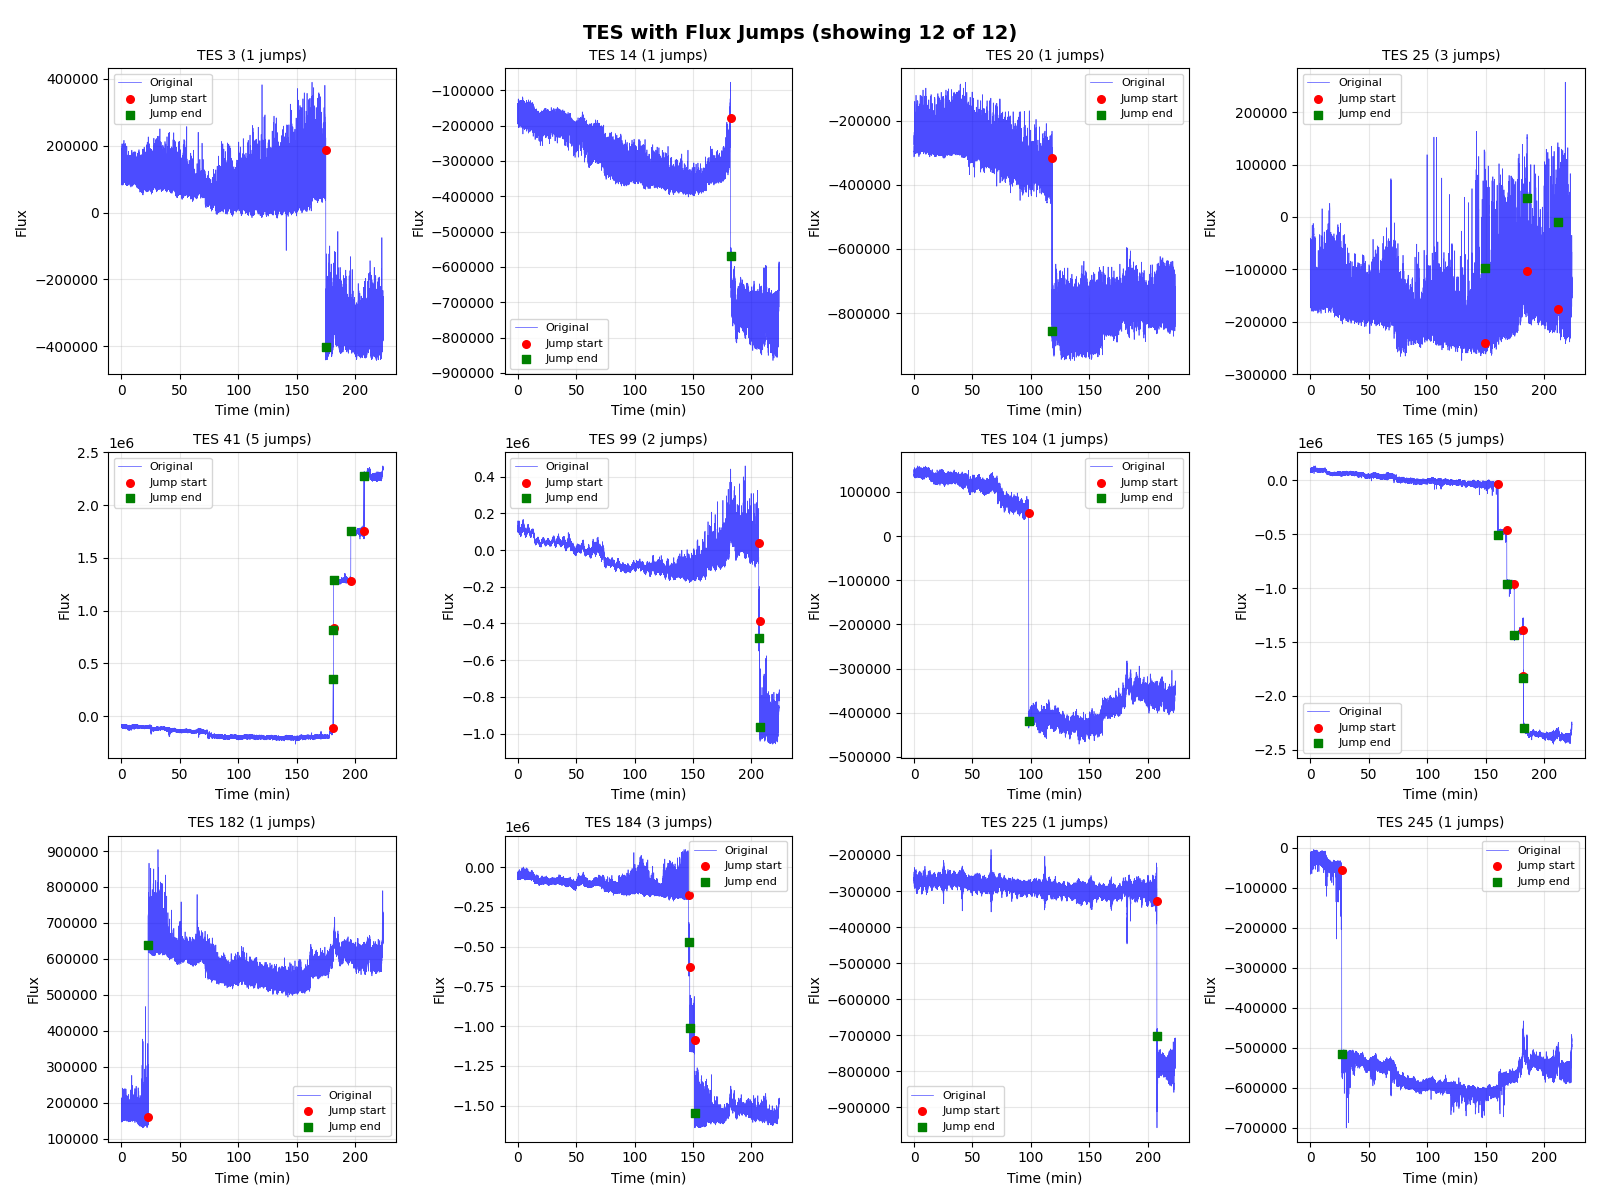

0

In [51]:
utils.plot_jump_detections(tt, todarray, results, DT=False)

In [54]:
# Step 2: Decision Tree Refinement
dt = jr.DT(thr_count=1e3, thr_amp=2.5e5, tol=1e2, depth=True)
dt_jump_data = {}
TES_with_dt_jumps = []
for idx in TES_yes:
    nc = jump_data[idx]['nc']
    xcdt, xcfdt = dt.calculate_levels(tt, todarray[idx], nc, consec=True)
    dt_jump_data[idx] = {'xcdt': xcdt, 'xcfdt': xcfdt, 'ncdt': len(xcdt)}
    if len(xcdt) > 0:
        TES_with_dt_jumps.append(idx)

In [55]:
results['dt_jump_data'] = dt_jump_data
results['TES_yes_dt'] = TES_with_dt_jumps

In [53]:
%matplotlib inline

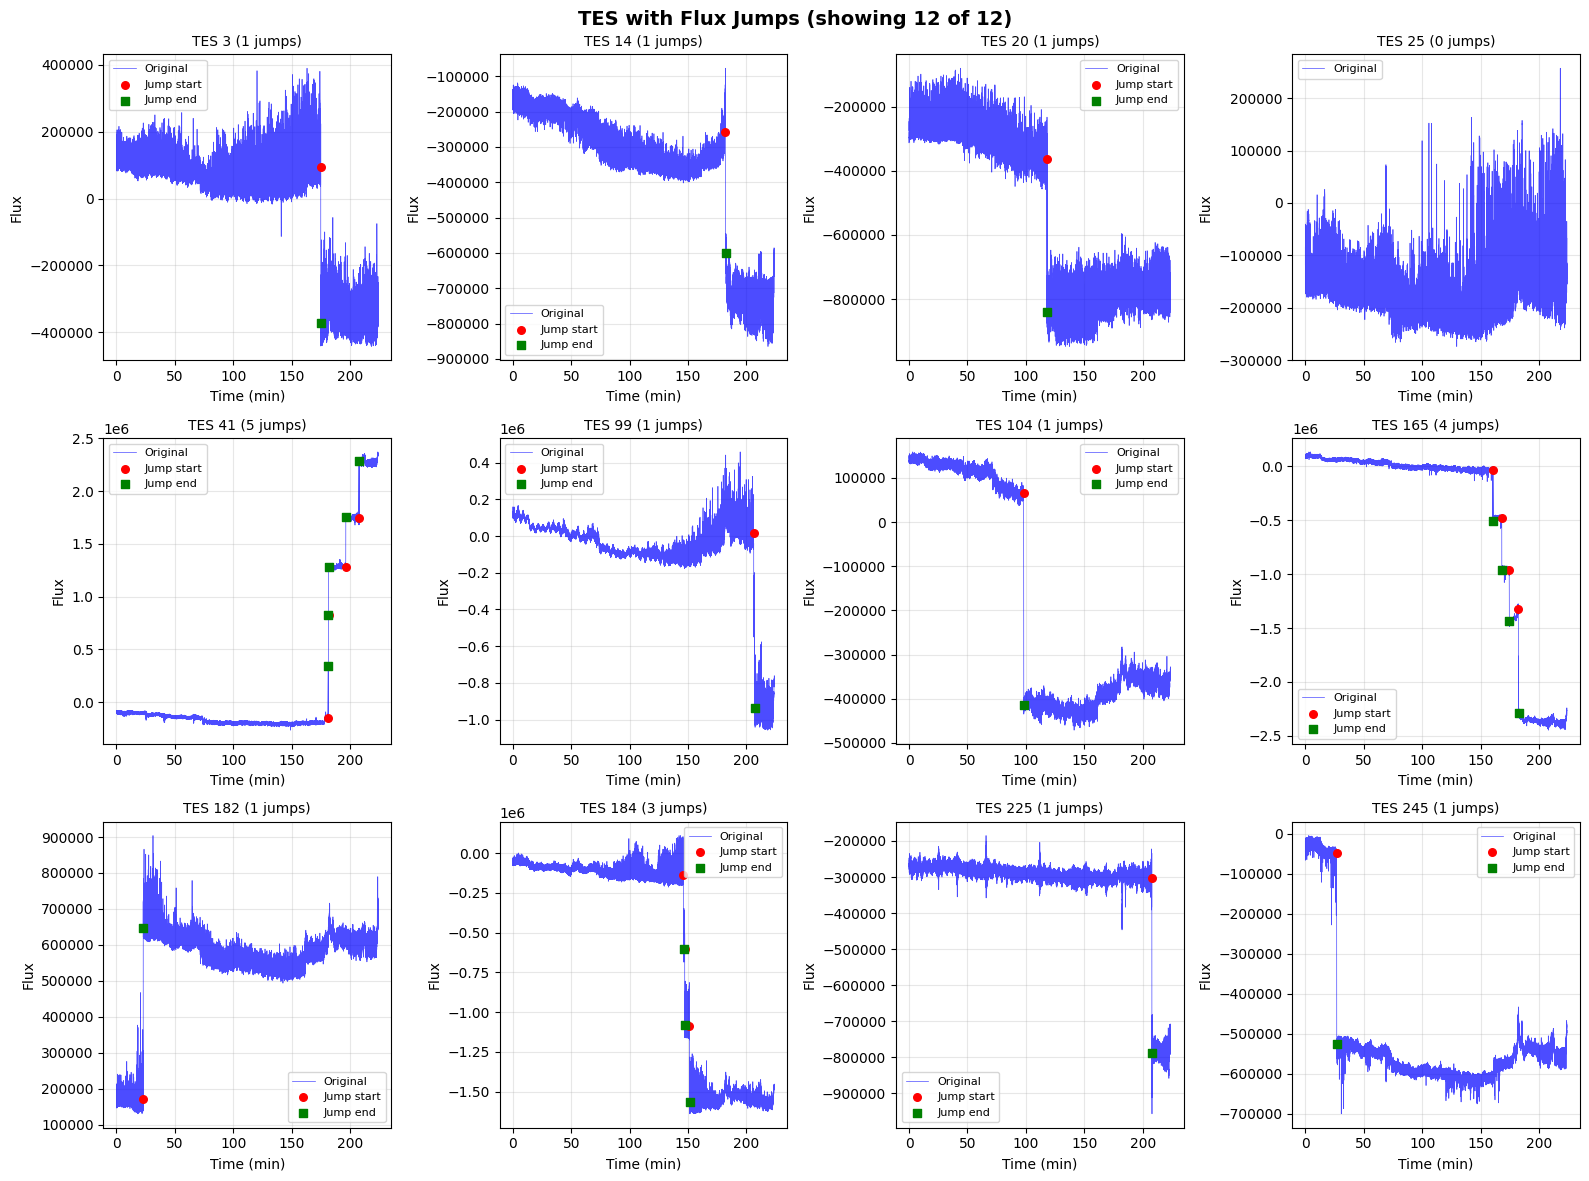

0

In [56]:
utils.plot_jump_detections(tt, todarray, results, DT=True)

In [57]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in dt_jump_data:
        xcdt = dt_jump_data[idx]['xcdt']
        xcfdt = dt_jump_data[idx]['xcfdt']
        nc_dt = dt_jump_data[idx]['ncdt']
        if nc_dt > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xcdt, xcfdt, nc_dt)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xcdt, xcfdt, nc_dt)

In [58]:
results['corrected_data'] = corrected_tod
results['offset'] = offset

/home/belen/miniconda3/envs/venv-qubic/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


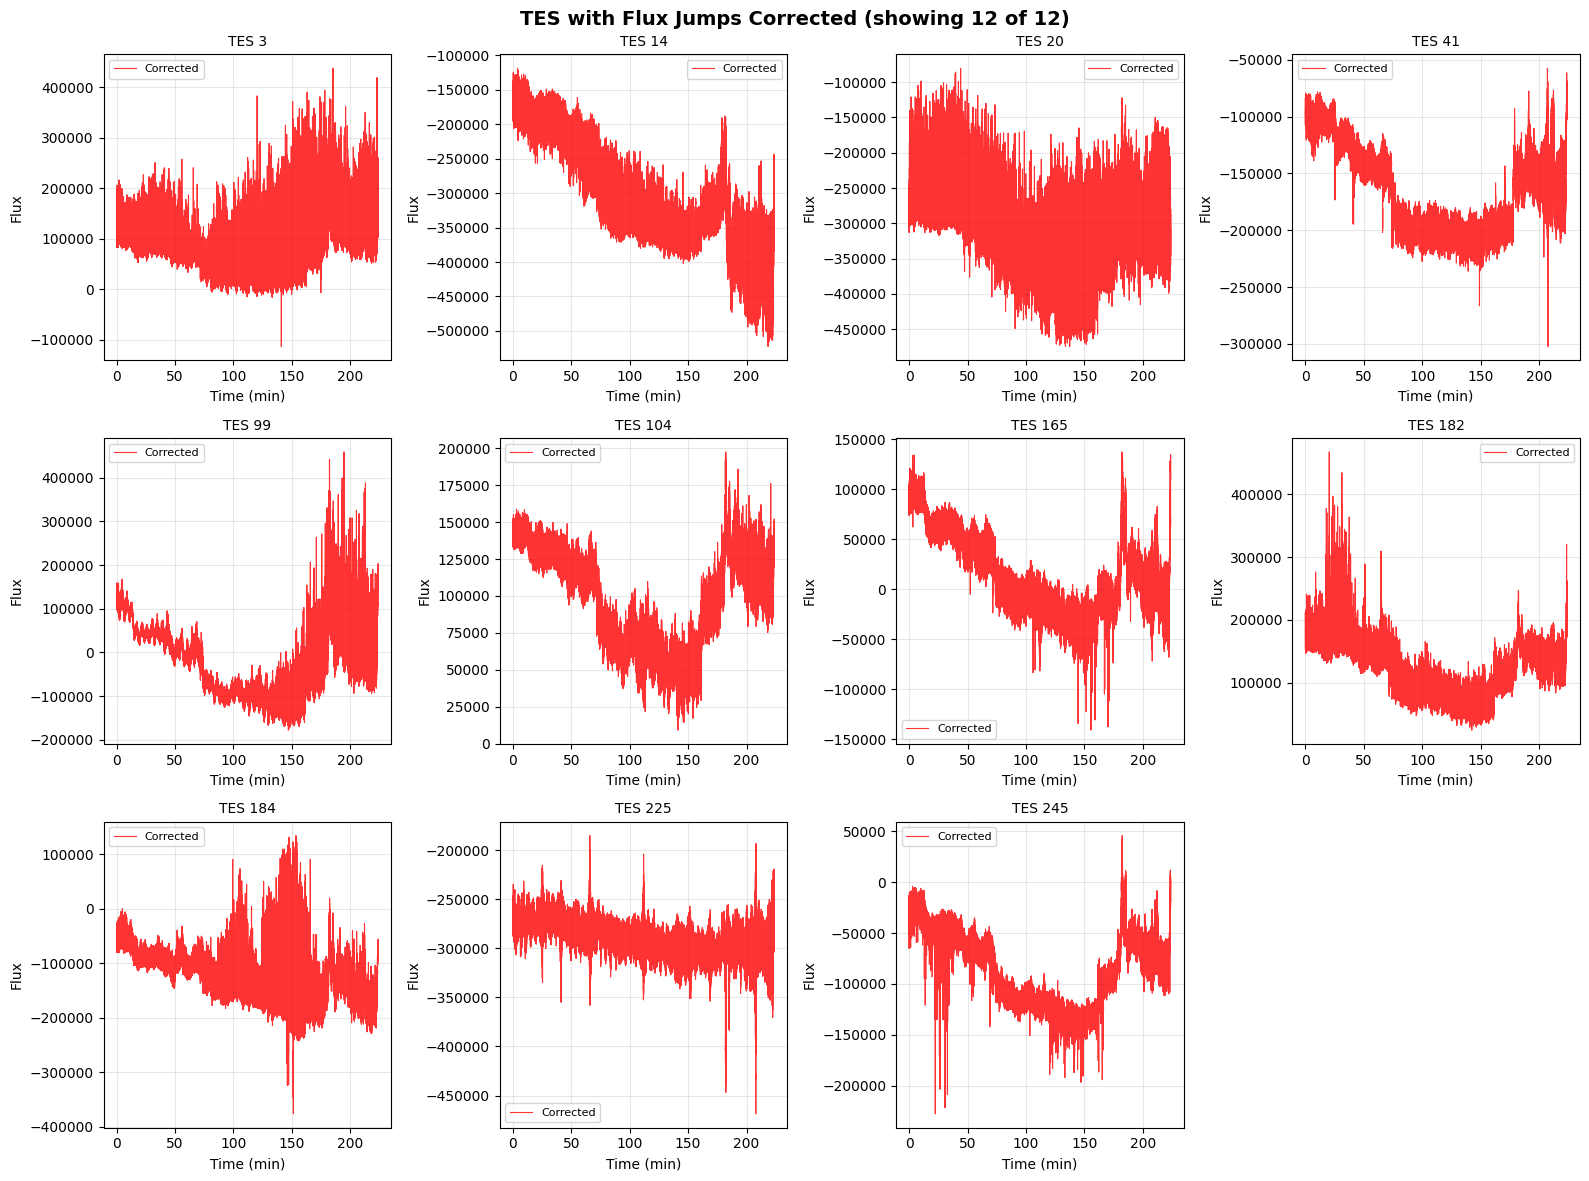

0

In [59]:
utils.plot_corrections(tt, todarray, results)

In [60]:
utils.save_results(results, output_dir=data_path + "year_23_day_2705_16.28.40", dataset_name="23_2705_16.28.40")

Saved pickle file to: ./day_2705_16.28.40/23_2705_16.28.40_results.pkl

All results saved to: ./day_2705_16.28.40
Total files saved: 1



['./day_2705_16.28.40/23_2705_16.28.40_results.pkl']